In [50]:
import torch
from chimera.losses.split_losses import VICRegLoss

In [54]:
test_1  = torch.rand((4,2))
test_2 = torch.rand((4,2))
loss = VICRegLoss()
loss(test_1,test_2)

(tensor(38.9522),
 {'repr': tensor(0.0863), 'std': tensor(1.4715), 'cov': tensor(0.0072)})

In [15]:
import argparse, yaml
from typing import Any, Dict, Tuple

def load_cfg(path: str) -> Dict[str, Any]:
    with open(path, "r") as f:
        return yaml.safe_load(f)
cfg = load_cfg(path="../configs/default.yaml")

In [18]:
cfg['model'].get('feature_size')

1024

In [29]:
import torch
torch.seed()
embedding1 = torch.randn(3)
embedding2 = torch.randn(3)
embedding3 = torch.randn(3)
print(embedding1, embedding2, embedding3, sep="\n")
sequence = torch.stack([embedding1, embedding2, embedding3], dim=1)
print("seq : \n" , sequence)
print(sequence.shape)  

tensor([ 0.5412, -0.0187,  0.7073])
tensor([ 0.9648, -0.5220,  2.6935])
tensor([ 0.4496,  0.9139, -0.5653])
seq : 
 tensor([[ 0.5412,  0.9648,  0.4496],
        [-0.0187, -0.5220,  0.9139],
        [ 0.7073,  2.6935, -0.5653]])
torch.Size([3, 3])


In [1]:
from chimera.models.vanp.pred_text import MultimodalPretrainModel
import torch 
from torch import nn

In [2]:
img_encoder    = nn.Sequential(nn.Flatten(), nn.Linear(3*64*64, 2048))
action_encoder = nn.Sequential(nn.Linear(6*2, 256), nn.ReLU(), nn.Linear(256, 256))  

cfg = {
    "feature_size": 512,
    "hidden_dim": 1024,
    "projection_dim": 2048,
    "action_encoder_type": "mlp",
    "dropout": 0.1,
    "nhead": 4,
    "num_layers": 2,
    "obs_len": 6,
    "n_registers": 2,
    "encoders": {
        "img": {"out_dim": 2048},
        "action": {"out_dim": 256}
    }
}

model = MultimodalPretrainModel(cfg=cfg, encoders={"img": img_encoder, "action": action_encoder})

/opt/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
B, T, L = 8, 6, 2
frames       = [torch.randn(B, 3, 64, 64) for i in range(T)]
future_frame = torch.randn(B, 3, 64, 64)
actions      = torch.randn(B, T, L)

In [7]:
out = model(frames, future_frame, actions)
out[0]

tensor([[-0.0053,  0.0567, -0.0021,  ...,  0.6699, -0.0031,  0.8462],
        [-0.0044,  0.0889,  0.4016,  ..., -0.0040,  0.2366,  0.5128],
        [ 0.0474, -0.0016,  0.3789,  ..., -0.0018, -0.0054, -0.0025],
        ...,
        [-0.0014,  0.0503,  0.0024,  ..., -0.0037, -0.0013, -0.0023],
        [ 0.0721, -0.0053,  0.2782,  ..., -0.0019,  0.6036, -0.0019],
        [-0.0027,  0.2210, -0.0054,  ..., -0.0104, -0.0052,  0.3264]],
       grad_fn=<CloneBackward0>)

In [1]:
from chimera.data.gnm_dataset import GNM2SocialNavDataset
import torch 
from torch.utils.data import DataLoader

/opt/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = GNM2SocialNavDataset(train=True, use_mask=True, resize=(98,126))

100%|██████████| 239/239 [00:19<00:00, 12.29it/s]


In [3]:
s = ds[0]
len(s["past_frames"]), s["future_frame"].shape, s.get("obs_traversability", None) is not None

(6, torch.Size([3, 98, 126]), True)

In [8]:
def socialnav_collate(batch):
    B = len(batch)
    out = {}
    # time-major: past_frames[t][B,3,H,W]
    T = len(batch[0]["past_frames"])
    out["past_frames"] = [torch.stack([batch[b]["past_frames"][t] for b in range(B)]) for t in range(T)]
    # остальные ключи
    for k in ["future_frame","future_positions","future_yaw","future_vw",
              "past_positions","past_yaw","past_vw","goal_direction","dt"]:
        out[k] = torch.stack([torch.as_tensor(batch[b][k]) for b in range(B)])
    if "obs_traversability" in batch[0]:
        out["obs_traversability"] = torch.stack([batch[b]["obs_traversability"] for b in range(B)])
    return out

loader = DataLoader(ds, batch_size=4, shuffle=True, collate_fn=socialnav_collate)
batch = next(iter(loader))
batch["goal_direction"].shape

torch.Size([4, 2])

In [3]:
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from chimera.data.gnm_dataset import GNM2SocialNavDataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

ds = GNM2SocialNavDataset(
    obs_len=6,
    pred_len=20,
    use_yaw=True,            # не критично для визуалки
    train=False,              # важное: включает аугментации
    resize=(98, 126),
    use_mask=True
)


print(f"Dataset size: {len(ds)} samples")

# 4) хелперы для "раз-нормализации" и перевода в HWC
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def to_numpy_img(t: torch.Tensor) -> np.ndarray:
    """
    t: [3, H, W] tensor normalized (ImageNet)
    return: [H, W, 3] uint8
    """
    if t.ndim != 3:
        raise ValueError(f"expected CHW, got shape {tuple(t.shape)}")
    x = t.detach().cpu() * IMAGENET_STD + IMAGENET_MEAN
    x = (x.clamp(0,1).permute(1,2,0).numpy() * 255).astype(np.uint8)
    return x

def to_numpy_mask(mask_t: torch.Tensor) -> np.ndarray:
    """
    mask_t: [1, H, W] or [H, W] float tensor in [0,1] (after ToTensor)
    return: [H, W] float in [0,1]
    """
    m = mask_t.detach().cpu()
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    m = m.clamp(0,1).numpy()
    return m

100%|██████████| 239/239 [00:19<00:00, 12.38it/s]


Dataset size: 36072 samples


/opt/venv/lib/python3.10/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")



=== sample #7296 ===
past_frames: 6 torch.Size([3, 98, 126])
future_frame: torch.Size([3, 98, 126])
obs_traversability: torch.Size([1, 98, 126])
goal_direction (radius, angle): [0.9999996423721313, 0.03099891170859337]   dt: 0.9090909361839294

=== sample #1639 ===
past_frames: 6 torch.Size([3, 98, 126])
future_frame: torch.Size([3, 98, 126])
obs_traversability: torch.Size([1, 98, 126])
goal_direction (radius, angle): [0.9999996423721313, -0.03142239898443222]   dt: 0.9444444179534912

=== sample #18024 ===
past_frames: 6 torch.Size([3, 98, 126])
future_frame: torch.Size([3, 98, 126])
obs_traversability: torch.Size([1, 98, 126])
goal_direction (radius, angle): [0.9999996423721313, 0.02619433030486107]   dt: 0.9411764740943909

=== sample #16049 ===
past_frames: 6 torch.Size([3, 98, 126])
future_frame: torch.Size([3, 98, 126])
obs_traversability: torch.Size([1, 98, 126])
goal_direction (radius, angle): [0.9999989867210388, 0.048001933842897415]   dt: 0.9333333373069763


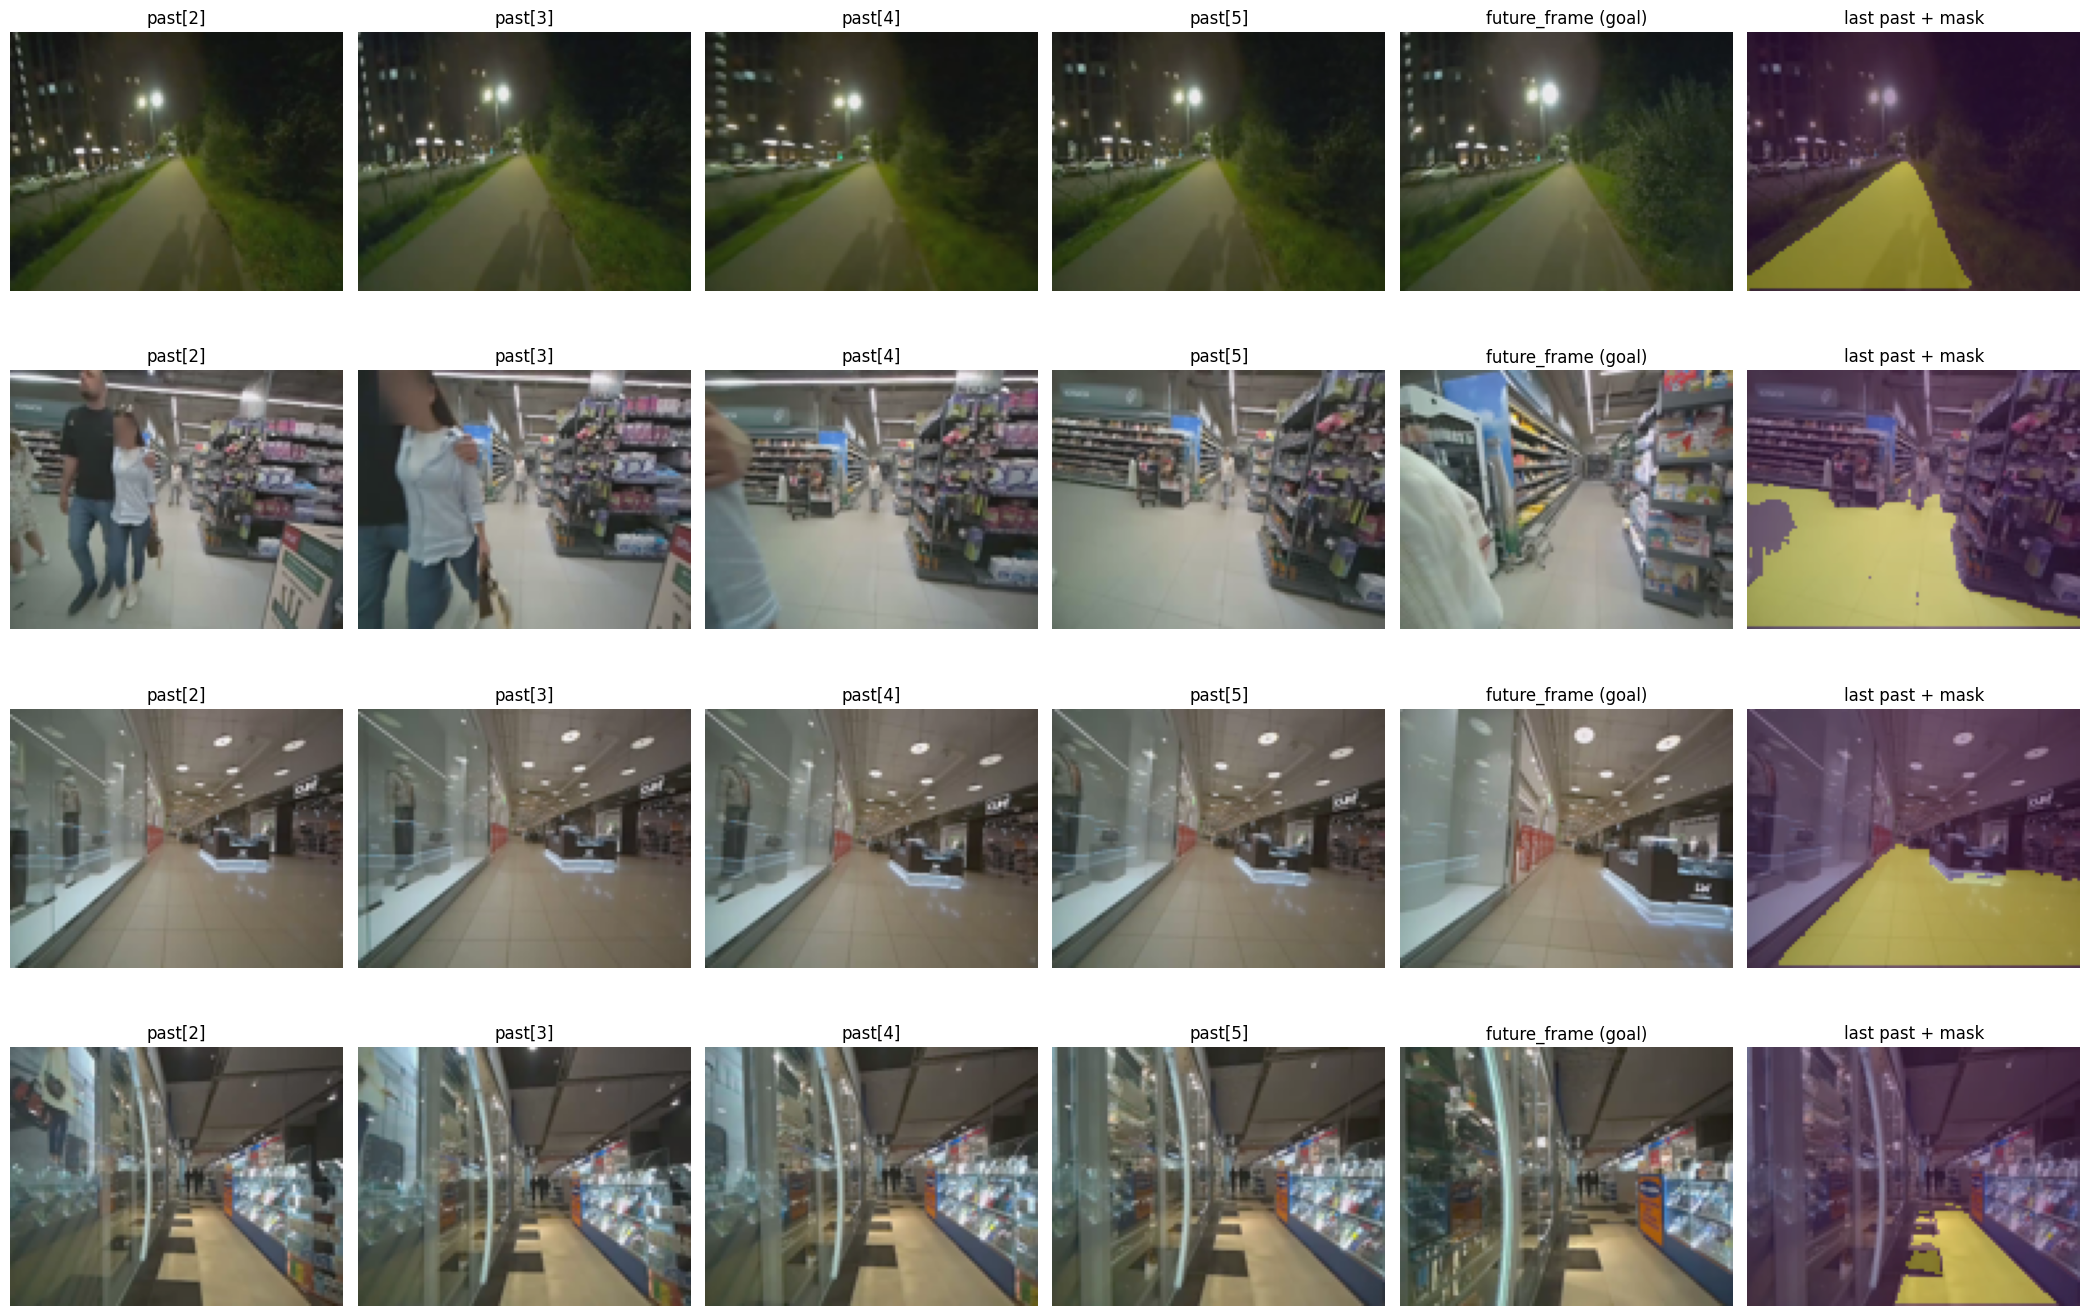

In [4]:
indices = random.sample(range(len(ds)), k=4)

n_cols = 4  # сколько past кадров показывать
fig, axes = plt.subplots(len(indices), n_cols + 2, figsize=(3.5*(n_cols+2), 3.5*len(indices)))
if len(indices) == 1:
    axes = np.expand_dims(axes, 0)

for row, idx in enumerate(indices):
    sample = ds[idx]

    past_frames = sample["past_frames"]                # list of tensors [3,H,W]
    future_frame = sample["future_frame"]              # tensor [3,H,W]
    goal_dir = sample["goal_direction"]                # [2]
    dt = sample["dt"]                                  # [1]
    mask = sample.get("obs_traversability", None)      # tensor [1,H,W] if present

    # печать форм для контроля совмещения
    print(f"\n=== sample #{idx} ===")
    print("past_frames:", len(past_frames), past_frames[0].shape)
    print("future_frame:", future_frame.shape)
    if mask is not None:
        print("obs_traversability:", mask.shape)
    print("goal_direction (radius, angle):", goal_dir.tolist(), "  dt:", dt.item())

    # конвертируем несколько past кадров
    show_count = min(n_cols, len(past_frames))
    for c in range(show_count):
        axes[row, c].imshow(to_numpy_img(past_frames[-show_count + c]))  # последние кадры ближе к текущему времени
        axes[row, c].set_title(f"past[{len(past_frames)-show_count+c}]")
        axes[row, c].axis("off")

    # future (goal) кадр как VANP "future_frame"
    axes[row, n_cols].imshow(to_numpy_img(future_frame))
    axes[row, n_cols].set_title("future_frame (goal)")
    axes[row, n_cols].axis("off")

    # наложение маски на последний past кадр (если есть)
    last_img = to_numpy_img(past_frames[-1])
    axes[row, n_cols+1].imshow(last_img)
    if mask is not None:
        m = to_numpy_mask(mask)
        # проверим совпадение размеров
        if m.shape != last_img.shape[:2]:
            # если вдруг что-то не совпало — аккуратно растянем до картинки
            from PIL import Image
            m = np.array(Image.fromarray((m*255).astype(np.uint8)).resize((last_img.shape[1], last_img.shape[0]), resample=Image.NEAREST)) / 255.0
        # полупрозрачное наложение
        axes[row, n_cols+1].imshow(m, alpha=0.35, cmap="viridis")
        axes[row, n_cols+1].set_title("last past + mask")
    else:
        axes[row, n_cols+1].set_title("last past (no mask)")
    axes[row, n_cols+1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# model/build_pretext.py
from typing import Literal, Optional, Tuple, Dict, Any, List
import torch
import torch.nn as nn
from torchvision import models
import yaml

# если у тебя уже есть свои утилиты — можно импортнуть их вместо моего простого MLP
def make_mlp(dims: List[int], activation: str = "relu", dropout: float = 0.0) -> nn.Sequential:
    act = {"relu": nn.ReLU, "gelu": nn.GELU, "tanh": nn.Tanh}[activation]
    layers: List[nn.Module] = []
    for i in range(len(dims) - 1):
        layers += [nn.Linear(dims[i], dims[i + 1])]
        if i < len(dims) - 2:
            layers += [act(inplace=True) if activation == "relu" else act(), nn.Dropout(dropout)]
    return nn.Sequential(*layers)

# ==== импорт твоего класса ====
# PretextModel должен совпадать с тем, что уже используется у тебя в проекте
from chimera.models.vanp.pred_text import MultimodalPretrainModel
from chimera.models.vanp.encoders import Transformer  # если нужен action-encoder типа "attn"

@torch.no_grad()
def _set_requires_grad(module: nn.Module, requires: bool):
    for p in module.parameters():
        p.requires_grad = requires

# def _build_image_backbone(
#     name: str = "resnet50",
#     pretrained: bool = True,
# ) -> nn.Module:
#     weights = "DEFAULT" if pretrained else None
#     # torchvision 0.15+: models.get_model
#     image_encoder = models.get_model(name.lower(), weights=weights, zero_init_residual=True)
#     # последний FC нам не нужен — голова проекции будет внутри PretextModel
#     if hasattr(image_encoder, "fc"):
#         image_encoder.fc = nn.Identity()
#     return image_encoder

def _build_action_encoder(
    encoder_type: Literal["mlp", "attn"],
    action_size: int,
    pred_len: int,
    cfg: Dict[str, Any],
    device: torch.device,
) -> nn.Module:
    if encoder_type == "mlp":
        # пример: dims=[1024,512,256] где вход добавляем как pred_len*action_size
        dims = [pred_len * action_size] + list(cfg["action_backbone"]["dims"])
        mlp = make_mlp(dims=dims,
                       activation=cfg["action_backbone"].get("activation", "relu"),
                       dropout=cfg["action_backbone"].get("dropout", 0.0))
        return mlp.to(device)
    elif encoder_type == "attn":
        # те же аргументы, что ты уже используешь в Learner.init_model
        attn = Transformer(
            n_layers=cfg["attn"]["num_layers"],
            d_model=cfg["attn"]["context_size"],
            n_head=cfg["attn"]["nhead"],
            n_action=action_size,
            d_hidden=cfg["attn"]["d_hid"],
            pred_len=pred_len,
            action_type=cfg["action_type"],
            dropout=cfg["attn"]["dropout"],
            n_registers=cfg["attn"]["n_registers"],
        )
        return attn.to(device)
    else:
        raise ValueError(f"Unknown action encoder type: {encoder_type}")

def build_pretext_model(
    cfg: Dict[str, Any]
) -> MultimodalPretrainModel:
    """
    Возвращает полностью собранный PretextModel по конфигу из твоего Learner.
    Ожидает, что в cfg есть секция 'model' (как у тебя).
    """
    device = cfg["device"]
    mcfg = cfg["model"]

    # 1) image backbone (ResNet и т.п.)
    img_backbone = _build_image_backbone(
        name=mcfg["img_backbone"]["name"],
        pretrained=mcfg["img_backbone"]["pretrained"],
    ).to(device)
    img_backbone.device = device  # твой код это использует

    # 2) action encoder (MLP или Transformer)
    action_encoder = _build_action_encoder(
        encoder_type=mcfg["action_encoder_type"],
        action_size=mcfg["action_size"],
        pred_len=mcfg["pred_len"],
        cfg=mcfg,
        device=device,
    )

    # 3) опционально заморозить action backbone
    if mcfg.get("freeze_action_backbone", False):
        _set_requires_grad(action_encoder, False)
        action_encoder.eval()

    # 4) собрать PretextModel с нужными гиперпараметрами
    pretext = MultimodalPretrainModel(
        encoders={"img": img_backbone, "action": action_encoder},
        cfg=mcfg
    ).to(device)

    return pretext


# =======================
# Мини‑проверка (sanity check)
# =======================
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("../configs/default.yaml", "r") as f:
    cfg = yaml.safe_load(f)
pretext = build_pretext_model(cfg, device)

    # # Синтетический батч
    # B, obs_len, H, W = 4, 6, 98, 126
    # past_frames: List[torch.Tensor] = [torch.rand(B, 3, H, W, device=device) for _ in range(obs_len)]
    # future_frame = torch.rand(B, 3, H, W, device=device)
    # future_actions = torch.rand(B, cfg["model"]["pred_len"], cfg["model"]["action_size"], device=device)

    # # без маски
    # outs = pretext(past_frames, future_frame, future_actions)
    # # ожидаем кортеж (что твой forward_batch потом разбирает):
    # # _, img_z, action_z, future_frame_z, mask_z
    # assert isinstance(outs, tuple) and len(outs) >= 4, "PretextModel must return at least 4 tensors"
    # _, img_z, action_z, future_frame_z, *maybe_mask = outs
    # print("[no mask]  img_z:", tuple(img_z.shape),
    #       "action_z:", tuple(action_z.shape),
    #       "future_frame_z:", tuple(future_frame_z.shape))

    # # с маской
    # if cfg["model"]["use_mask"]:
    #     mask = (torch.rand(B, 1, H, W, device=device) > 0.5).float()
    #     outs_m = pretext(past_frames, future_frame, future_actions, mask)
    #     _, img_z_m, action_z_m, future_frame_z_m, mask_z_m = outs_m
    #     print("[with mask] img_z:", tuple(img_z_m.shape),
    #           "action_z:", tuple(action_z_m.shape),
    #           "future_frame_z:", tuple(future_frame_z_m.shape),
    #           "mask_z:", tuple(mask_z_m.shape))

/opt/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TypeError: MultimodalPretrainModel.__init__() missing 2 required positional arguments: 'encoders' and 'cfg'

In [1]:
from typing import Literal, Optional, Tuple, Dict, Any, List
import torch
import torch.nn as nn
from torchvision import models
import yaml

# если у тебя уже есть свои утилиты — можно импортнуть их вместо моего простого MLP
def make_mlp(dims: List[int], activation: str = "relu", dropout: float = 0.0) -> nn.Sequential:
    act = {"relu": nn.ReLU, "gelu": nn.GELU, "tanh": nn.Tanh}[activation]
    layers: List[nn.Module] = []
    for i in range(len(dims) - 1):
        layers += [nn.Linear(dims[i], dims[i + 1])]
        if i < len(dims) - 2:
            layers += [act(inplace=True) if activation == "relu" else act(), nn.Dropout(dropout)]
    return nn.Sequential(*layers)

# ==== импорт твоего класса ====
# PretextModel должен совпадать с тем, что уже используется у тебя в проекте
from chimera.models.vanp.pred_text import MultimodalPretrainModel
from chimera.models.vanp.encoders import Transformer  # если нужен action-encoder типа "attn"
with open("../configs/default.yaml", "r") as f:
    cfg = yaml.safe_load(f)

In [3]:
def _build_action_encoder(
    encoder_type: Literal["mlp", "attn"],
    action_size: int,
    pred_len: int,
    mcfg: Dict[str, Any],
    device: torch.device,
) -> nn.Module:
    if encoder_type.lower() == "mlp":
        # dims_cfg = mcfg.get("action_backbone", {}).get("dims", None)
        # if not dims_cfg:
        #     raise ValueError("For action_encoder_type=mlp you must set model.action_backbone.dims in YAML.")
        # in_dim = pred_len * action_size
        # dims = [in_dim] + list(dims_cfg)
        # activation = mcfg.get("action_backbone", {}).get("act", "relu")
        # dropout = float(mcfg.get("action_backbone", {}).get("dropout", 0.0))
        # mlp = make_mlp(dims=dims, activation=activation, dropout=dropout).to(device)
        # return mlp
        raise NotImplementedError

    elif encoder_type.lower() == "attn":
        attn = Transformer(
            n_layers=mcfg["attn"]["num_layers"],
            d_model=mcfg["attn"]["context_size"],
            n_head=mcfg["attn"]["nhead"],
            n_action=action_size,
            d_hidden=mcfg["attn"]["d_hid"],
            pred_len=pred_len,
            action_type=mcfg["action_type"],
            dropout=mcfg["attn"]["dropout"],
            n_registers=mcfg["attn"]["n_registers"],
        ).to(device)
        return attn

    else:
        raise ValueError(f"Unknown action_encoder_type={encoder_type}")
    

_build_action_encoder(encoder_type=cfg['model']["action_encoder_type"],
                      action_size=cfg['model']['action_size'],
                      pred_len=cfg['model']['pred_len'],
                      mcfg=cfg['model'],
                      device=cfg["device"])

Transformer(
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=1024, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=1024, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.4, inplace=False)
        (dropout2): Dropout(p=0.4, inplace=False)
      )
    )
  )
  (patch_embedding): PatchEmbedding(
    (linear): Linear(in_features=2, out_features=128, bias=True)
    (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (positional_encoding): PositionalEncoding()
  (regression_head): RegressionHead(
    (linear1): 

In [4]:
def _build_image_backbone(name: str, pretrained: bool) -> nn.Module:
    weights = "DEFAULT" if pretrained else None
    enc = models.get_model(name.lower(), weights=weights, zero_init_residual=True)
    # выкинем классификатор
    if hasattr(enc, "fc"):
        enc.fc = nn.Identity()
    elif hasattr(enc, "classifier"):
        enc.classifier = nn.Identity()
    return enc

In [5]:
img_name = cfg['model']["img_backbone"]["name"]
img_pretrained = bool(cfg['model']["img_backbone"].get("pretrained", False))
img_backbone = _build_image_backbone(img_name, img_pretrained).to(cfg['device'])
img_backbone

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
def build_pretext_model(
    cfg: Dict[str, Any],
    device
) -> MultimodalPretrainModel:
    device = device
    img_name = cfg["img_backbone"]["name"]
    img_pretrained = bool(cfg["img_backbone"].get("pretrained", False))
    img_backbone = _build_image_backbone(img_name, img_pretrained).to(device)
    
    action_encoder = _build_action_encoder(encoder_type=cfg["action_encoder_type"],
                      action_size=cfg['action_size'],
                      pred_len=cfg['pred_len'],
                      mcfg=cfg,
                      device=device)
    
    if cfg.get("freeze_action_backbone", False):
        _set_requires_grad(action_encoder, False)
        action_encoder.eval()

    # 4) собрать PretextModel с нужными гиперпараметрами
    pretext = MultimodalPretrainModel(
        encoders={"img": img_backbone, "action": action_encoder},
        cfg=cfg
    ).to(device)

    return pretext
    

pretext = build_pretext_model(cfg=cfg['model'], device=cfg['device'])

pretext

/opt/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


MultimodalPretrainModel(
  (encoders): ModuleDict(
    (img): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu

In [17]:
B, T, L = 64, 20, 2
frames       = [torch.randn(B, 3, 64, 64,device=cfg['device']) for i in range(6)]
future_frame = torch.randn(B, 3, 64, 64,device=cfg['device'])
actions      = torch.randn(B, T, L,device=cfg['device'])
print(f"frames shape: {frames[0].shape}")

frames shape: torch.Size([64, 3, 64, 64])


In [28]:
out = pretext(frames, future_frame, actions)

out[1].shape

torch.Size([64, 1024])

In [2]:
import torch
import yaml
from chimera.models.vanp.build_pred_text import build_pretext_model

with open("../configs/default.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    
pretext = build_pretext_model(cfg=cfg['model'], device=cfg['device'])

/opt/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [4]:
B, T, L = 64, 20, 2
frames       = [torch.randn(B, 3, 64, 64,device=cfg['device']) for i in range(6)]
future_frame = torch.randn(B, 3, 64, 64,device=cfg['device'])
actions      = torch.randn(B, T, L,device=cfg['device'])

out = pretext(frames, future_frame, actions)

out[1].shape

torch.Size([64, 1024])